In [112]:
# hydrologic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_hydrologic_attributes.csv")
# climatic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_climatic_attributes.csv")
# topography = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_topographic_attributes.csv")
# hydrogeology = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_hydrogeology_attributes.csv")
# landcover = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_landcover_attributes.csv")
# soil = pd.read_csv(home_dir + 'Catchment_Attributes/CAMELS_GB_v2_soil_attributes.csv')

In [113]:
# cols = landcover.filter(like='dwood_perc_').columns
# landcover['dwood_perc_mean'] = landcover[cols].mean(axis=1)

# cols = landcover.filter(like='ewood_perc_').columns
# landcover['ewood_perc_mean'] = landcover[cols].mean(axis=1)

# landcover['all_wood_mean'] = landcover['dwood_perc_mean'] + landcover['ewood_perc_mean']

In [109]:
import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt

home_dir = "/scratch/hydro4/shared_data/uk_catchment_data/camels_gb_v2/"
# os.listdir(home_dir + 'Catchment_Attributes')

# 0. Data set-up stages

In [111]:
hydrologic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_hydrologic_attributes.csv")
climatic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_climatic_attributes.csv")

# 1. Precipitation vs runoff

What is the relationship between mean precipitation and mean runoff?

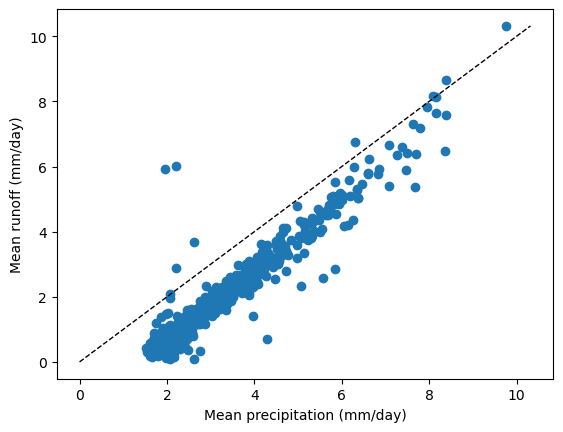

In [116]:
plt.scatter(climatic_attributes['p_mean'], hydrologic_attributes['q_mean'])
plt.xlabel('Mean precipitation (mm/day)')
plt.ylabel('Mean runoff (mm/day)')

max_val = max(climatic_attributes['p_mean'].max(), hydrologic_attributes['q_mean'].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1);

In [132]:
# from shapely import Point
# import geopandas as gpd
# # Get just the gauge location information
# # Construct the geometry from the latitude and longitude using Shapely
# geometry = [Point(xy) for xy in zip(merged.gauge_lon, merged.gauge_lat)]
# # Create the geodataframe
# # gauge_locs = topography.drop(['gauge_lon', 'gauge_lat'], axis=1)
# merged_gdf = gpd.GeoDataFrame(merged, crs="EPSG:4326", geometry=geometry)

In [133]:
# merged_gdf_3857 = merged_gdf.to_crs(epsg=3857)
# some = merged_gdf_3857.sort_values('runoff_ratio', ascending=False)#[:8]

# import contextily as ctx

# fig,ax=plt.subplots(figsize=(8,8))
# some.plot('runoff_ratio', ax=ax,  markersize=15, )
# # some.plot('runoff_ratio', ax=ax, markersize=15, legend=True, # cmap='Purples',
# #             legend_kwds={"label": "Days / yr", "orientation": "vertical"})
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

Question: Why do some catchments produce more runoff than others?

- Generally a positive relationship
- But, also a large spread in values
- 

# 2. — Baseflow Index vs Runoff Sensitivity
Question: Do catchment properties affect river behaviour?

Runoff sensitivity (or flow variability) tells us how strongly a catchment responds to rainfall variability.

Two catchments can receive similar rainfall but behave very differently:

Buffered catchments (high groundwater storage)
        → rainfall variability is smoothed
        → river flows change slowly

Flashy catchments (little storage)
        → rainfall variability is amplified
        → large swings in river flow

So predicting runoff sensitivity answers the question:

Why do some catchments respond strongly to rainfall while others smooth it out?

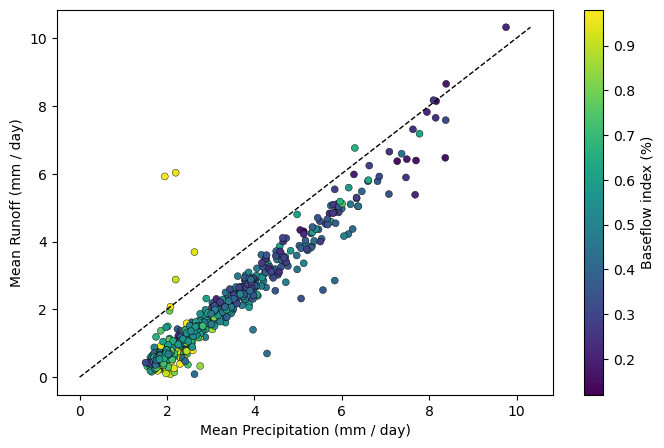

In [119]:
plt.figure(figsize=(8,5))

sc = plt.scatter(
    merged['p_mean'],
    merged['q_mean'],
    c=merged['baseflow_index_ceh'],
    cmap='viridis', s=25, edgecolor = 'black', linewidth=0.3)

plt.xlabel('Mean Precipitation (mm / day)')
plt.ylabel('Mean Runoff (mm / day)')

plt.colorbar(sc, label='Baseflow index (%)')

max_val = max(climatic_attributes['p_mean'].max(), hydrologic_attributes['q_mean'].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1);

# 3. Can we predict how catchments behave from their characteristics?

#### Join into one

In [134]:
# test = hydrologic_attributes['Q95'] - hydrologic_attributes['Q5']
# plt.hist(test)
# hydrologic_attributes[hydrologic_attributes['gauge_id'] ==13008]
# climatic_attributes[climatic_attributes['gauge_id'] ==13008]

In [135]:
merged = (topography
        .merge(climatic_attributes, on="gauge_id", how="left")
#         .merge(hydrologic_attributes, on="gauge_id", how="left")
         .merge(hydrogeology, on="gauge_id", how="left"))
merged['baseflow_index_ceh'] = hydrologic_attributes['baseflow_index_ceh'].copy()
merged['baseflow_index'] = hydrologic_attributes['baseflow_index'].copy()
merged['runoff_ratio'] = hydrologic_attributes['runoff_ratio'].copy()
merged['q_mean'] = hydrologic_attributes['q_mean'].copy()
merged['all_wood_mean'] = landcover['all_wood_mean'].copy()

In [126]:
# merged.sort_values(by='flow_variability')

In [139]:
merged['flow_variability'] = (hydrologic_attributes['Q95'] - hydrologic_attributes['Q5']) / hydrologic_attributes['q_mean']
# plt.scatter(merged['baseflow_index'], merged['flow_variability'])

In [137]:
# plt.figure(figsize=(6,6))

# sc = plt.scatter(
#     merged['gauge_lon'],
#     merged['gauge_lat'],
#     c=merged['flow_variability'],
#     cmap='coolwarm'
# )

# plt.colorbar(sc, label='Flow variability')
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")

In [140]:
X = merged[['p_mean',
            'pet_mean',
            'baseflow_index',
            'dpsbar',
            'elev_mean',
            'all_wood_mean',
       'elev_min', 'elev_10', 'elev_50', 'elev_90', 'elev_max',
            'gauge_easting',
       'gauge_northing',
            'aridity', 'p_seasonality', 'frac_snow', 'high_prec_freq',
       'high_prec_dur',  'low_prec_freq', 'low_prec_dur',
      'inter_high_perc', 'inter_mod_perc',
       'inter_low_perc', 'frac_high_perc', 'frac_mod_perc', 'frac_low_perc',
       'no_gw_perc', 'low_nsig_perc', 'nsig_low_perc', 'baseflow_index_ceh'
           ]]

y = merged['flow_variability']

In [144]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X, y)
predictions = rf_model.predict(X)

print("\nClimate + Groundwater model")
# print("Intercept:", model2.intercept_)
# print("Slope:", model2.coef_[0])
print("R2:", r2_2)
print("RMSE:", rmse_2)



Climate + Groundwater model
R2: 0.9811875437775178
RMSE: 0.094454745036487


<Axes: >

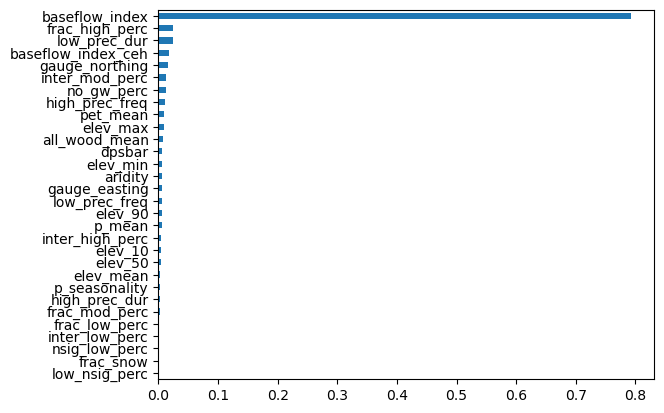

In [142]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

# Relationship between flow and precipitation
Load in datasets that we used before...  
Get dataframe with gauge locations and topographic variables

## Building a model to predict the influence of catchment characteristics on runoff

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import multiprocessing
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import numpy as np

Create a very basic model

Climate-only model
R2: 0.9514771457829987
RMSE: 0.348548089232332


In [31]:
low_bfi = merged[merged['baseflow_index'] < 0.5].copy()
high_bfi = merged[merged['baseflow_index'] > 0.5].copy()
print(len(low_bfi), len(high_bfi))

333 322


In [35]:
# Predictor variable (must be 2D for sklearn)
X = low_bfi[['p_mean']].values
# Response variable
y = low_bfi['q_mean'].values

# Create a linear regression model
model1 = LinearRegression()
# model1 = RandomForestRegressor()
model1.fit(X, y)

# Predictions
low_bfi['q_pred'] = model1.predict(X)

# Model performance
r2_1 = r2_score(y, low_bfi['q_pred'])
rmse_1 = np.sqrt(mean_squared_error(y, low_bfi['q_pred']))

print("Climate-only model")
print("R2:", r2_1)
print("RMSE:", rmse_1)

Climate-only model
R2: 0.9539719815980541
RMSE: 0.37856042363063713


In [36]:
# Predictor variable (must be 2D for sklearn)
X = high_bfi[['p_mean']].values
# Response variable
y = high_bfi['q_mean'].values

# Create a linear regression model
model1 = LinearRegression()
# model1 = RandomForestRegressor()
model1.fit(X, y)

# Predictions
high_bfi['q_pred'] = model1.predict(X)

# Model performance
r2_1 = r2_score(y, high_bfi['q_pred'])
rmse_1 = np.sqrt(mean_squared_error(y, high_bfi['q_pred']))

print("Climate-only model")
print("R2:", r2_1)
print("RMSE:", rmse_1)

Climate-only model
R2: 0.779766245260547
RMSE: 0.5254336310653733


Deciding on the input variables

In [ ]:
# The predictor variables
# Xfull = topography.drop(['gauge_id', 'gauge_name', 'gauge_easting', 'gauge_northing'], axis =1)
Xfull = merged.drop(['gauge_id', 'gauge_name', 'gauge_easting', 'gauge_northing', 
                     'low_prec_timing', 'high_prec_timing', #Strings
#                     "slope_fdc" # Contains nan
                    ], axis =1)
# Xfull = merged[['p_mean', 'pet_mean', 'baseflow_index']]
# The variable to be predicted
Yfull = hydrologic_attributes['q_mean'].values

Train test split

In [60]:
X_train, X_test, y_train, y_test = train_test_split( Xfull, Yfull,test_size=0.2, random_state=42)

Fit a linear model

In [61]:
lin_model = Pipeline([("scaler", StandardScaler()),("model", LinearRegression())])
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

Fit a random forest model

In [62]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Fit XGB model

In [63]:
xgb_model = XGBRegressor( n_estimators=300,learning_rate=0.05,max_depth=4,subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

Evaluate model performance

In [64]:
def evaluate(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)}

results = pd.DataFrame({"Linear Regression": evaluate(y_test, y_pred_lin),"Random Forest": evaluate(y_test, y_pred_rf),
    "XGBoost": evaluate(y_test, y_pred_xgb)})

print(results)

      Linear Regression  Random Forest   XGBoost
R2             0.881506       0.899170  0.903151
RMSE           0.563490       0.519798  0.509431
MAE            0.268847       0.261308  0.275788


In [53]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lin = LinearRegression()

r2_lin = cross_val_score(lin, Xfull, Yfull, cv=kf, scoring='r2')
rmse_lin = -cross_val_score(lin, Xfull, Yfull, cv=kf,
                            scoring='neg_root_mean_squared_error')

print("Linear Regression")
print("Mean R2:", r2_lin.mean())
print("Mean RMSE:", rmse_lin.mean())

Linear Regression
Mean R2: 0.9917311552069675
Mean RMSE: 0.14062590824224255


In [54]:
rf = RandomForestRegressor(random_state=42)

r2_rf = cross_val_score(rf, Xfull, Yfull, cv=kf, scoring='r2')
rmse_rf = -cross_val_score(rf, Xfull, Yfull, cv=kf,
                           scoring='neg_root_mean_squared_error')

print("Random Forest")
print("Mean R2:", r2_rf.mean())
print("Mean RMSE:", rmse_rf.mean())

Random Forest
Mean R2: 0.9793584156995381
Mean RMSE: 0.21755788181777067


In [88]:
xgb = XGBRegressor(random_state=42)

r2_xgb = cross_val_score(xgb, Xfull, Yfull, cv=kf, scoring='r2')
rmse_xgb = -cross_val_score(xgb, Xfull, Yfull, cv=kf,
                            scoring='neg_root_mean_squared_error')

print("XGBoost")
print("Mean R2:", r2_xgb.mean())
print("Mean RMSE:", rmse_xgb.mean())

XGBoost
Mean R2: 0.8988254122665392
Mean RMSE: 0.4948708345762788


 Feature importance (Random Forest)

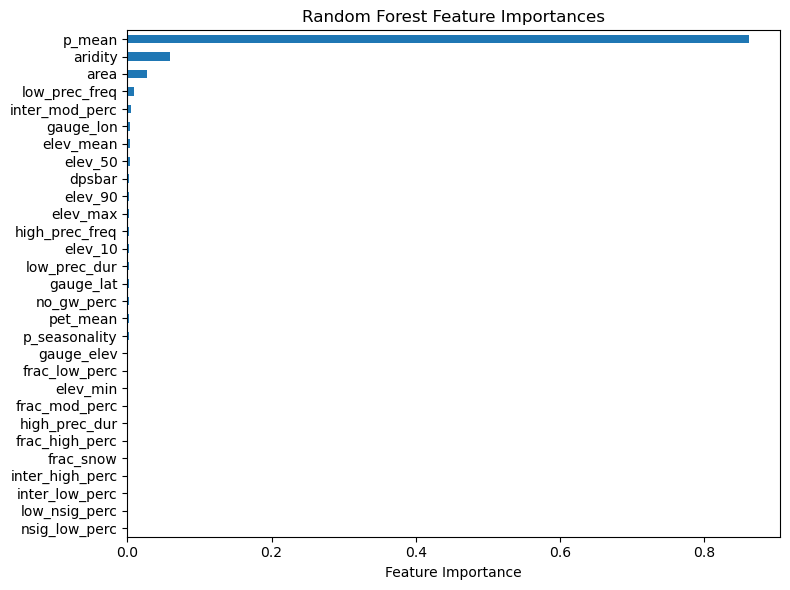

In [65]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500,random_state=42, n_jobs=-1)
rf.fit(Xfull, Yfull)
importances = pd.Series(rf.feature_importances_,index=Xfull.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()

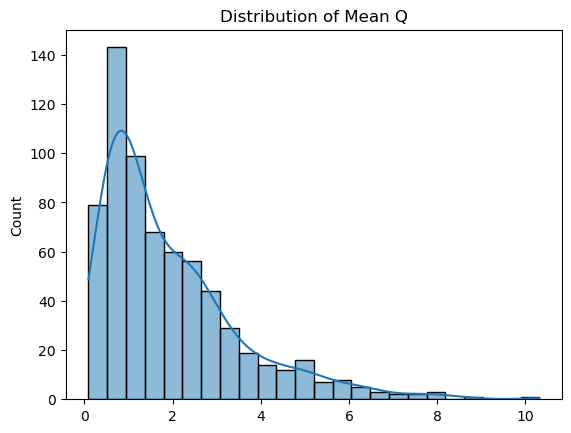

Skewness: 1.589289746830567


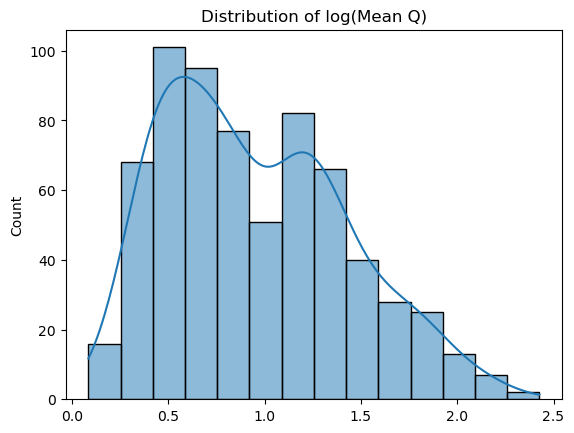

In [58]:
import seaborn as sns

sns.histplot(Yfull, kde=True)
plt.title("Distribution of Mean Q")
plt.show()

from scipy.stats import skew

print("Skewness:", skew(Yfull))

import numpy as np

sns.histplot(np.log1p(Yfull), kde=True)
plt.title("Distribution of log(Mean Q)")
plt.show()

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(Xfull, Yfull, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

residuals = y_test - y_pred

In [63]:
rf_raw = RandomForestRegressor(random_state=42)
rf_raw.fit(X_train, y_train)
r2_raw = rf_raw.score(X_test, y_test)
y_pred_raw = rf_raw.predict(X_test)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

rf_log = RandomForestRegressor(random_state=42)
rf_log.fit(X_train, y_train_log)

y_pred_log = rf_log.predict(X_test)
y_pred_back = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_back)

print(r2_raw, r2_log)

rmse_raw = np.sqrt(mean_squared_error(y_test, y_pred_raw))
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_back))
print(r2_raw, r2_log)

0.8393826750829971 0.8217707875761211
0.8393826750829971 0.8217707875761211


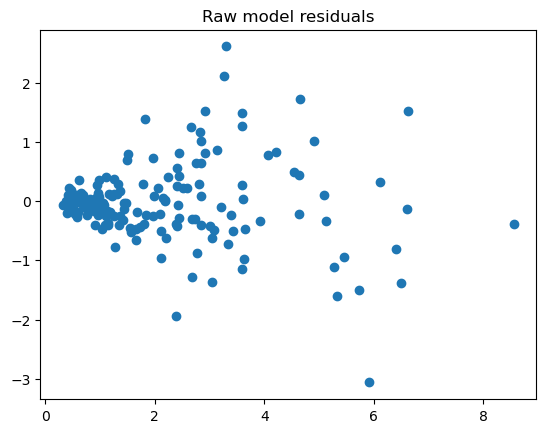

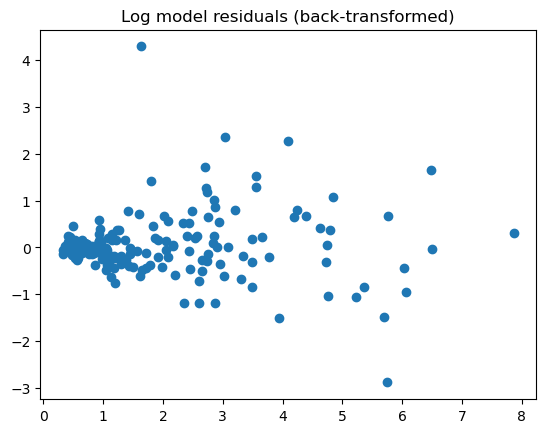

In [64]:
plt.scatter(y_pred_raw, y_test - y_pred_raw)
plt.title("Raw model residuals")
plt.show()

plt.scatter(y_pred_back, y_test - y_pred_back)
plt.title("Log model residuals (back-transformed)")
plt.show()


In [35]:
# Split data into training and test sets
X_train, X_temp, Y_train, Y_temp = \
    train_test_split(Xfull, Yfull, test_size=0.6666, random_state=123)
# Split off another training set now to train the hyperparameters using the two best models from above
X_validate, X_finaltest, Y_validate, Y_finaltest = \
    train_test_split(X_temp, Y_temp, test_size=0.5, random_state=123)

In [107]:
# climatic_attributes = pd.read_csv(home_dir + "Catchment_Timeseries/Hydro-Meteorological/Daily/CAMELS_GB_v2_hydromet_daily_timeseries_10002_19701001-20220930.csv")
# climatic_attributes.head()

In [61]:
# cachment_boundaries = gpd.read_file(home_dir + "Catchment_Boundaries/CAMELS_GB_v2_catchment_boundaries.shp")
# # cachment_boundaries.plot()

In [79]:
# nrfa = gpd.read_file("/scratch/hydro4/shared_data/uk_catchment_data/shapefile_boundaries/NRFACatchmentsAll-2024.shp")
# nrfa.plot(color = 'None', linewidth= 1)
# nrfa.crs